In [1]:
import pandas as pd

file = r"C:\Users\ronit\Downloads\UK Cost Of Living Project\Data\Raw\Consumer price inflation tables\2026.xlsx"

In [2]:
table2 = pd.read_excel(
    file,
    sheet_name="Table 2",
    header=None
)


In [3]:
table2.head(25)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Back to Content,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Table 2,"CPIH: Detailed figures by division 1,2,3",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,,,,"Housing,","Furniture,",,,,,,,Miscell-,
5,NaN,NaN,Food and,Alcoholic,,"water,",household,,,,,,,aneous,
6,NaN,NaN,non-,beverages,Clothing,"electricity,",equipment,,,,Recreation,,NaN,goods,CPIH
7,NaN,NaN,alcoholic,and,and,gas &,& routine,,,Communic-,and,,Restaurants,and,(overall
8,NaN,NaN,beverages,tobacco,footwear,other fuels,maintenance,Health,Transport,ation,culture,Education,and hotels,services,index)
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
table37 = pd.read_excel(
    file,
    sheet_name="Table 37",
    header=None
)
table37.head(25)
table37.shape
table37.iloc[:20:15]

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,180
0,Back to Contents,THE FIGURES IN THIS TABLE ARE NOT accredited o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,198809,1988-09-01 00:00:00,48.716,48.765,48.866,51.483,54.874,42.837,49.56,47.904,...,37.632,37.836,34.578,23.517,50.048,81.748,28.338,49.507,49.131,50.05


In [5]:
table37.iloc[6, :].tolist()
for col in table37.columns:
    print(col, ":", table37.iloc[6,col])
category_names = table37.iloc[6]


0 : index date   
1 : name
2 : CPIH ALL ITEMS
3 : FOOD AND NON-ALCOHOLIC BEVERAGES
4 : FOOD
5 : BREAD & CEREALS
6 : MEAT
7 : FISH
8 : MILK, CHEESE & EGGS
9 : OILS & FATS
10 : FRUIT
11 : VEGETABLES INCLUDING POTATOES AND TUBERS
12 : SUGAR, JAM, SYRUPS, CHOCOLATE AND CONFECTIONERY
13 : FOOD PRODUCTS (NEC)
14 : NON-ALCOHOLIC BEVERAGES
15 : COFFEE, TEA & COCOA
16 : MINERAL WATERS, SOFT DRINKS AND JUICES
17 : ALCOHOLIC BEVERAGES AND TOBACCO
18 : ALCOHOLIC BEVERAGES
19 : SPIRITS
20 : WINE
21 : BEER
22 : TOBACCO
23 : CLOTHING AND FOOTWEAR
24 : CLOTHING
25 : GARMENTS
26 : OTHER CLOTHING & CLOTHING ACCESSORIES
27 : CLEANING, REPAIR AND HIRE OF CLOTHING
28 : FOOTWEAR INCLUDING REPAIRS
29 : HOUSING, WATER, ELELCTRICITY, GAS AND OTHER FUELS
30 : ACTUAL RENTALS FOR HOUSING
31 : OOH
32 : REGULAR MAINTENANCE AND REPAIR OF THE DWELLING
33 : MATERIALS FOR MAINTENANCE AND REPAIR
34 : SERVICES FOR MAINTENANCE AND REPAIR
35 : WATER SUPPLY AND MISC. SERVICES FOR THE DWELLING
36 : WATER SUPPLY
37 : SEWERAGE

In [6]:
for category in category_names:
    if isinstance(category, str):
        if (
            "CPIH ALL ITEMS" in category
            or "FOOD AND NON-ALCOHOLIC BEVERAGES" in category
            or "CLOTHING AND FOOTWEAR" in category
            or "HOUSING, WATER, ELECTRICITY, GAS AND OTHER FUELS" in category
            or "TRANSPORT" in category
            or "RESTAURANTS AND HOTELS" in category
        ):
            print(category)

CPIH ALL ITEMS
FOOD AND NON-ALCOHOLIC BEVERAGES
CLOTHING AND FOOTWEAR
TRANSPORT
OPERATION OF PERSONAL TRANSPORT EQUIPMENT
OTHER SERVICES IN RESPECT OF PERSONAL TRANSPORT EQ
TRANSPORT SERVICES
PASSENGER TRANSPORT BY RAILWAY
PASSENGER TRANSPORT BY ROAD
PASSENGER TRANSPORT BY AIR
PASSENGER TRANSPORT BY SEA AND INLAND WATERWAY
RESTAURANTS AND HOTELS
TRANSPORT INSURANCE


Filtering: categories that were more most relevant in my opinion were chosen to demonstrate differences

In [7]:
categories = table37.iloc[7:, [2]].copy()
categories.columns = ["Date"]
categories.head()
categories["Date"] = pd.to_datetime(categories["Date"])
categories["Year"] = categories["Date"].dt.year

In [8]:
for col in table37.columns:
    name = table37.iloc[6, col]
    
    if isinstance(name, str):
        if any(term in name for term in [
            "CPIH ALL ITEMS",
            "FOOD AND NON-ALCOHOLIC BEVERAGES",
            "CLOTHING AND FOOTWEAR",
            "HOUSING, WATER, ELECTRICITY, GAS AND OTHER FUELS",
            "TRANSPORT",
            "RESTAURANTS AND HOTELS"
        ]):
            print(col, ":", name)

2 : CPIH ALL ITEMS
3 : FOOD AND NON-ALCOHOLIC BEVERAGES
23 : CLOTHING AND FOOTWEAR
65 : TRANSPORT
70 : OPERATION OF PERSONAL TRANSPORT EQUIPMENT
74 : OTHER SERVICES IN RESPECT OF PERSONAL TRANSPORT EQ
75 : TRANSPORT SERVICES
76 : PASSENGER TRANSPORT BY RAILWAY
77 : PASSENGER TRANSPORT BY ROAD
78 : PASSENGER TRANSPORT BY AIR
79 : PASSENGER TRANSPORT BY SEA AND INLAND WATERWAY
106 : RESTAURANTS AND HOTELS
122 : TRANSPORT INSURANCE


In [9]:
for col in table37.columns:
    name = table37.iloc[6, col]
    
    if isinstance(name, str):
        if "HOUSING" in name:
            print(col, ":", name)

29 : HOUSING, WATER, ELELCTRICITY, GAS AND OTHER FUELS
30 : ACTUAL RENTALS FOR HOUSING


In [10]:
table37.iloc[6, :10]

0                       index date   
1                                name
2                      CPIH ALL ITEMS
3    FOOD AND NON-ALCOHOLIC BEVERAGES
4                                FOOD
5                     BREAD & CEREALS
6                                MEAT
7                                FISH
8                 MILK, CHEESE & EGGS
9                         OILS & FATS
Name: 6, dtype: object

In [11]:
table37.iloc[7, :10]

0                 198801
1    1988-01-01 00:00:00
2                 46.851
3                 47.901
4                 48.244
5                 50.053
6                 53.741
7                 43.321
8                 48.488
9                 45.461
Name: 7, dtype: object

In [12]:
categories = table37.iloc[7:, [1,2,3,23,29,65,106]].copy()
categories.columns = [
    "Date",
    "CPIH",
    "Food",
    "Clothing",
    "Housing",
    "Transport",
    "Restaurants_Hotels"
]
categories.head()

,Date,CPIH,Food,Clothing,Housing,Transport,Restaurants_Hotels
7,1988-01-01 00:00:00,46.851,47.901,191.973,38.714,40.338,32.871
8,1988-02-01 00:00:00,46.998,48.174,193.181,38.791,40.317,33.025
9,1988-03-01 00:00:00,47.202,48.324,194.76,38.993,40.559,33.115
10,1988-04-01 00:00:00,47.801,48.592,195.128,39.763,41.075,33.526
11,1988-05-01 00:00:00,48.044,48.714,197.851,40.011,41.217,33.67


In [13]:
categories["Date"] = pd.to_datetime(
    categories["Date"],
    errors = "coerce"
)

In [14]:
categories = categories.dropna(subset= ["Date"]).copy()
categories.tail()

,Date,CPIH,Food,Clothing,Housing,Transport,Restaurants_Hotels
464,2026-02-01,139.962,144.318,118.67,143.165,137.455,152.201
465,2026-03-01,140.755,144.806,119.356,143.681,140.704,153.212
466,2026-04-01,141.839,144.853,119.881,144.292,145.741,154.707
467,2026-05-01,142.113,144.693,120.194,144.377,146.259,155.576
468,2026-06-01,142.341,144.417,118.788,144.676,145.82,157.072


In [15]:
categories["Year"] = categories["Date"].dt.year
categories.head()

,Date,CPIH,Food,Clothing,Housing,Transport,Restaurants_Hotels,Year
7,1988-01-01,46.851,47.901,191.973,38.714,40.338,32.871,1988
8,1988-02-01,46.998,48.174,193.181,38.791,40.317,33.025,1988
9,1988-03-01,47.202,48.324,194.76,38.993,40.559,33.115,1988
10,1988-04-01,47.801,48.592,195.128,39.763,41.075,33.526,1988
11,1988-05-01,48.044,48.714,197.851,40.011,41.217,33.67,1988


In [16]:
categories = categories[
    (categories["Year"] >= 2015) &
    (categories["Year"] <= 2025)
].copy()
categories.head
categories.tail

<bound method NDFrame.tail of           Date     CPIH     Food Clothing  Housing Transport  \
331 2015-01-01   99.241  101.294    97.97   99.448    98.091   
332 2015-02-01   99.464  101.025   99.292   99.498    98.457   
333 2015-03-01    99.64   100.85   99.231    99.43    99.213   
334 2015-04-01   99.897  100.484   99.946   99.742   100.332   
335 2015-05-01  100.063  100.428  100.485   99.834   100.936   
..         ...      ...      ...      ...      ...       ...   
458 2025-08-01  138.867   143.16  118.281  140.587   141.703   
459 2025-09-01  138.936  142.876  121.065  141.032   138.445   
460 2025-10-01  139.454  143.604  122.248  141.668     138.5   
461 2025-11-01  139.361  143.329  121.858  142.253   137.329   
462 2025-12-01  139.892  144.445  122.038  142.478   139.178   

    Restaurants_Hotels  Year  
331             98.857  2015  
332             99.087  2015  
333              99.32  2015  
334              99.57  2015  
335             99.769  2015  
..             

In [17]:
categories.shape

(132, 8)

In [18]:
categories.isna().sum()

Date                  0
CPIH                  0
Food                  0
Clothing              0
Housing               0
Transport             0
Restaurants_Hotels    0
Year                  0
dtype: int64

In [19]:
annual_categories = (
    categories
    .groupby("Year")
    .mean(numeric_only=True)
    .reset_index()
)
annual_categories

,Year
0,2015
1,2016
2,2017
3,2018
4,2019
5,2020
6,2021
7,2022
8,2023
9,2024


In [20]:
annual_categories.shape

(11, 1)

In [21]:
category_columns = [
    "CPIH",
    "Food",
    "Clothing",
    "Housing",
    "Transport",
    "Restaurants_Hotels"
]

In [22]:
category_columns = [
    "CPIH",
    "Food",
    "Clothing",
    "Housing",
    "Transport",
    "Restaurants_Hotels"
]

for column in category_columns:
    categories[column] = pd.to_numeric(
        categories[column],
        errors="coerce"
    )


In [23]:
categories.isna().sum()

Date                  0
CPIH                  0
Food                  0
Clothing              0
Housing               0
Transport             0
Restaurants_Hotels    0
Year                  0
dtype: int64

In [24]:
annual_categories = (
    categories
    .groupby("Year")
    .mean(numeric_only=True)
    .reset_index()
)
annual_categories

,Year,CPIH,Food,Clothing,Housing,Transport,Restaurants_Hotels
0,2015,100.000083,99.999917,100.000083,99.999833,100.000000,100.000000
1,2016,100.986167,97.610000,100.167083,101.633250,100.525250,102.398250
2,2017,103.590333,99.824750,102.640250,103.743667,104.889833,105.618083
3,2018,105.955667,101.904000,103.486417,105.650083,109.415500,108.396917
4,2019,107.803417,103.303000,102.585917,107.411583,111.601417,111.286750
5,2020,108.883583,104.038333,101.164750,108.353333,112.045417,112.323000
6,2021,111.614417,104.340000,101.440833,110.645417,120.160167,116.205333
7,2022,120.457667,115.756083,109.138500,120.080500,134.294750,125.856250
8,2023,128.640167,132.627417,116.515417,127.905750,134.733250,137.647167
9,2024,132.857167,136.188833,119.481750,132.542167,134.195333,144.752833


In [25]:
base_2015 = annual_categories[
    annual_categories["Year"] == 2015
].iloc[0]

base_2015

Year                  2015.000000
CPIH                   100.000083
Food                    99.999917
Clothing               100.000083
Housing                 99.999833
Transport              100.000000
Restaurants_Hotels     100.000000
Name: 0, dtype: float64

In [26]:
for column in category_columns:
    annual_categories[f"{column}_Change"] = (
        (annual_categories[column] / base_2015[column] - 1) * 100
    )


In [27]:
annual_categories.tail(1)

,Year,CPIH,Food,Clothing,Housing,Transport,Restaurants_Hotels,CPIH_Change,Food_Change,Clothing_Change,Housing_Change,Transport_Change,Restaurants_Hotels_Change
10,2025,137.99,141.901833,119.741083,140.14975,137.709333,149.579333,37.989885,41.901952,19.740984,40.149984,37.709333,49.579333


In [28]:
category_summary = pd.DataFrame({
    "Category": [
        "Overall CPIH",
        "Food",
        "Clothing",
        "Housing",
        "Transport",
        "Restaurants & Hotels"
    ],
    "Price Change from 2015-2025": [
        annual_categories.loc[
            annual_categories["Year"] == 2025, "CPIH_Change"
        ].iloc[0],
        annual_categories.loc[
            annual_categories["Year"] == 2025, "Food_Change"
        ].iloc[0],
        annual_categories.loc[
            annual_categories["Year"] == 2025, "Clothing_Change"
        ].iloc[0],
        annual_categories.loc[
            annual_categories["Year"] == 2025, "Housing_Change"
        ].iloc[0],
        annual_categories.loc[
            annual_categories["Year"] == 2025, "Transport_Change"
        ].iloc[0],
        annual_categories.loc[
            annual_categories["Year"] == 2025, "Restaurants_Hotels_Change"
        ].iloc[0]
    ]
})

category_summary

,Category,Price Change from 2015-2025
0,Overall CPIH,37.989885
1,Food,41.901952
2,Clothing,19.740984
3,Housing,40.149984
4,Transport,37.709333
5,Restaurants & Hotels,49.579333


In [29]:
category_summary = category_summary.sort_values(
    "Price Change from 2015-2025",
    ascending=False
)
category_summary

,Category,Price Change from 2015-2025
5,Restaurants & Hotels,49.579333
1,Food,41.901952
3,Housing,40.149984
0,Overall CPIH,37.989885
4,Transport,37.709333
2,Clothing,19.740984


In [30]:
import matplotlib.pyplot as plt

In [31]:
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


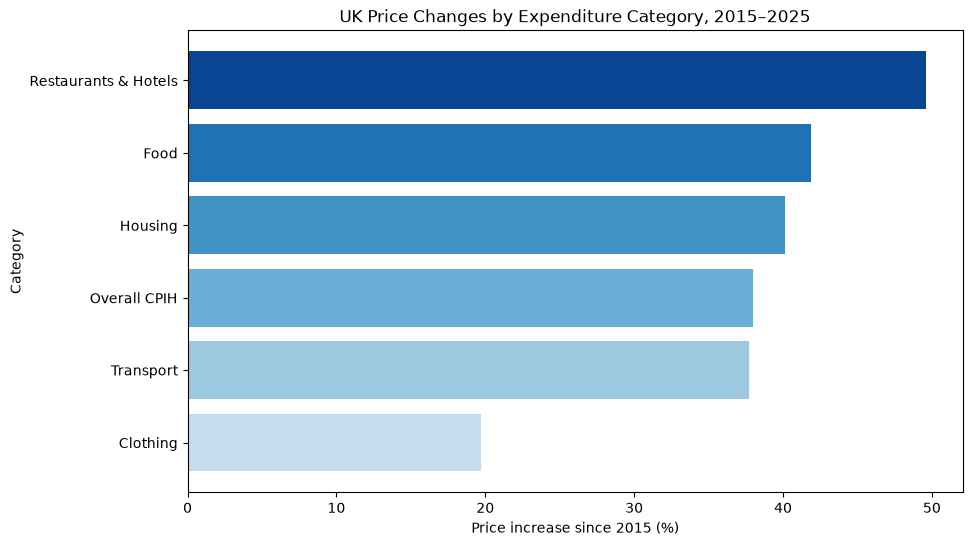

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Generate 6 shades of blue
n = 6
colors = plt.cm.Blues(np.linspace(0.3, 0.9, n))

plt.barh(
    category_summary["Category"],
    category_summary["Price Change from 2015-2025"],
    color = [
         "#084594",   
         "#2171b5",    
         "#4292c6",    
         "#6baed6",
         "#9ecae1",   
         "#c6dbef" 

    ],

    edgecolor="none"   # removes borders
)

plt.xlabel("Price increase since 2015 (%)")
plt.ylabel("Category")
plt.title("UK Price Changes by Expenditure Category, 2015–2025")

plt.gca().invert_yaxis()
plt.show()


Visualtion: Create a bar chart, matching the colours of the dashboard colour scheme to illustrate how CPIH variations occured

In [33]:
category_summary.to_csv("price_changes_expenditure.csv", index=False)
